# Plotting Module Tester

In [2]:
import cj_plotter

In [3]:
cj_plotter.__file__

'/home/cj517/miniconda3/envs/music/lib/python3.11/site-packages/cj_plotter.py'

In [3]:
from music_scripts.musicdata import MusicData

In [16]:
sim = MusicData('z2_data/r_min0.4_r_max0.9_from2d_v0_Om0/params_sample.nml')

In [4]:
from music_scripts.derived_fields import temp
T = temp(sim[2000])
T_arr = T.array()
T_slice = T_arr[:,:,0]

In [4]:
import numpy as np

In [6]:
T_r = np.mean(np.mean(T_arr, axis=2), axis=1)
dT = T_slice - T_r[:, np.newaxis]

In [11]:
r_tot = 70774597466.3827

In [51]:
r = sim[2000].grid.r_grid.cell_points()
t = sim[2000].grid.theta_grid.cell_points()
p = sim[2000].grid.phi_grid.cell_points()

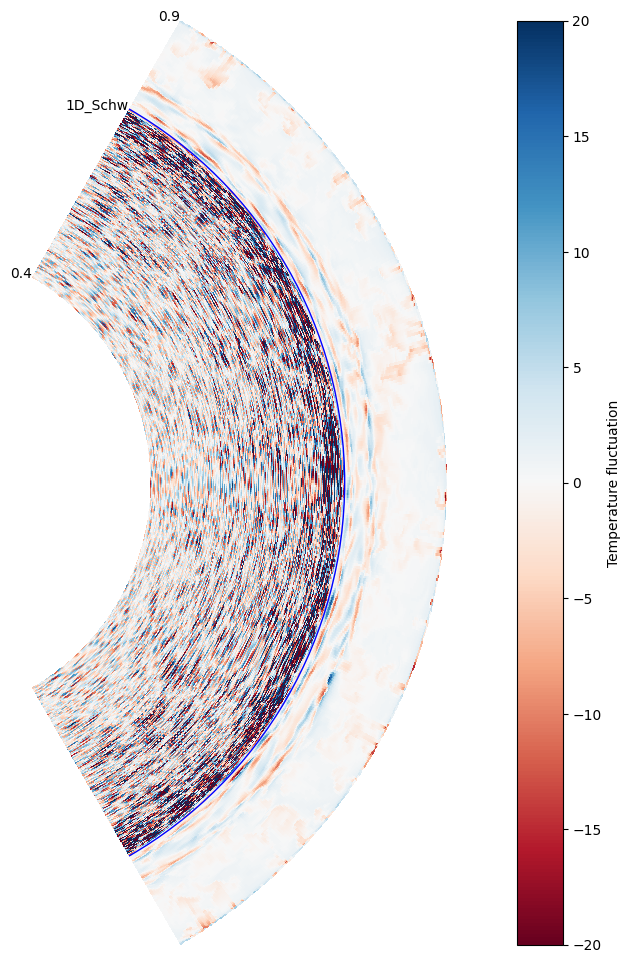

In [9]:
example_plot = cj_plotter.plot2D(t, r/r_tot, dT, -20, 20, cmap='RdBu', visible_ax=False)

example_plot.add_arc(5.149819426617924E+10/r_tot, edgecolor='blue', label='1D_Schw')
example_plot.colorbar(label='Temperature fluctuation')
# example_plot.zone(0.45,0.55, hatch='///', ec='r', fc='none')
# example_plot.savefig('test.png', bbox_inches = 'tight', dpi=150)

In [10]:
T_fluc = (T_slice / T_r[:, np.newaxis]) - 1

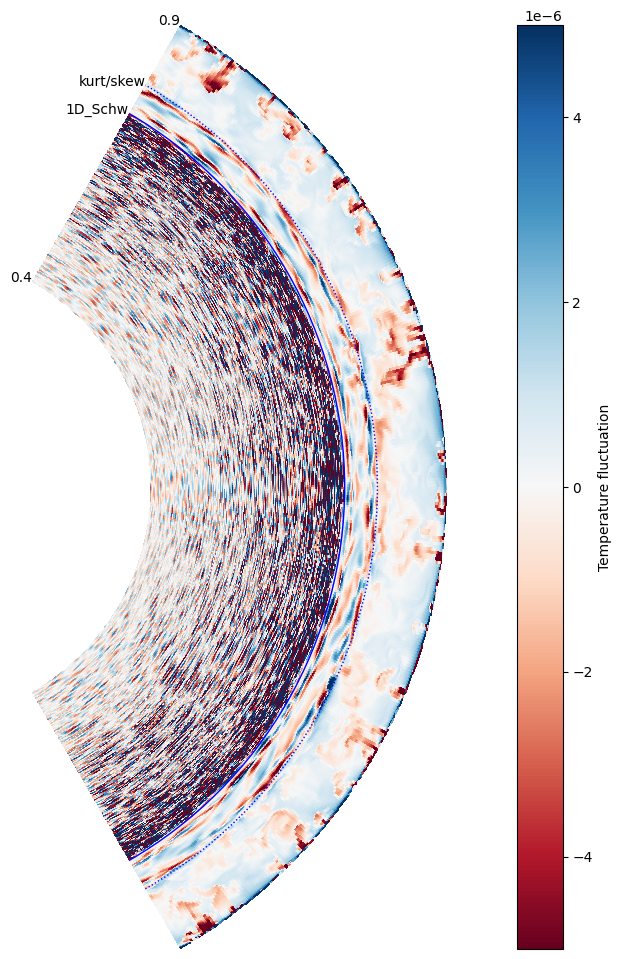

In [11]:
example_plot = cj_plotter.plot2D(t, r/r_tot, T_fluc, -5e-6, 5e-6, cmap='RdBu', visible_ax=False)

example_plot.add_arc(5.149819426617924E+10/r_tot, edgecolor='blue', label='1D_Schw')
example_plot.add_arc(55412016190.5/r_tot, edgecolor='blue', linestyle=':', label='kurt/skew')
example_plot.colorbar(label='Temperature fluctuation')

In [12]:
vel_1 = sim[2000].field['vel_1'].array()[:,:,0]

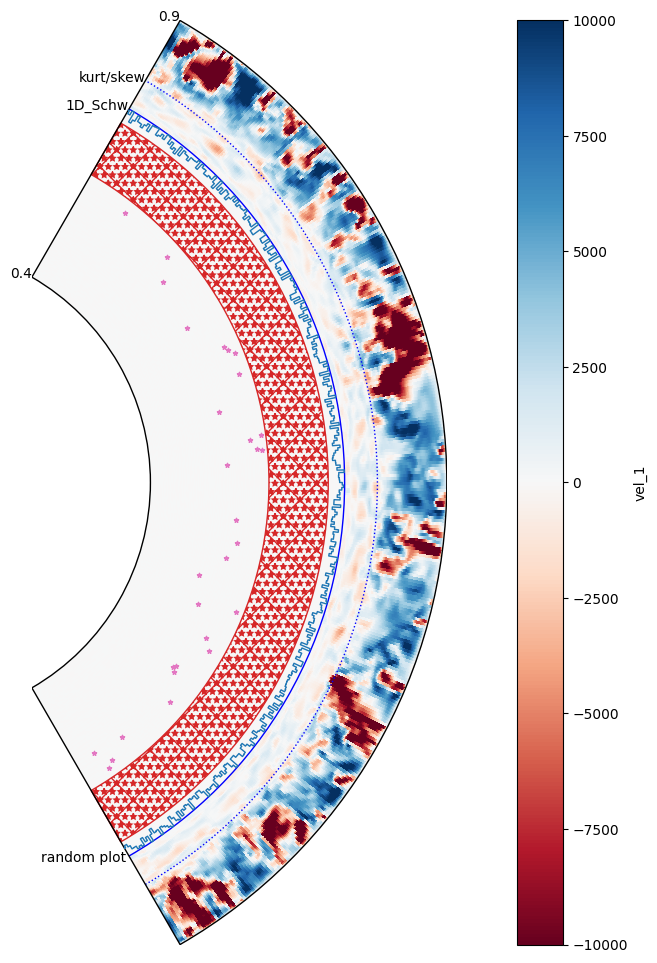

In [13]:
example_plot = cj_plotter.plot2D(t, r/r_tot, vel_1, -1e4, 1e4, cmap='RdBu') # , visible_ax=False)

example_plot.add_arc(5.149819426617924E+10/r_tot, edgecolor='blue', label='1D_Schw')
example_plot.add_arc(55412016190.5/r_tot, edgecolor='blue', linestyle=':', label='kurt/skew')
example_plot.colorbar(label='vel_1')

example_plot.zone(0.6, 0.7, hatch='X**', ec='tab:red', fc='none')

r_test = np.random.uniform(0.5, 0.6, size=30)
t_test = np.random.uniform(np.radians(30), np.radians(150), size=30)
example_plot.scatter(t_test, r_test, marker='*', s=10, c='tab:pink')

n = 360
r_test = np.random.uniform(5.149819426617924E+10/r_tot - 0.02, 5.149819426617924E+10/r_tot, size=n)
t_test = np.linspace(np.radians(30), np.radians(150), n)
example_plot.step(t_test, r_test, linestyle='-', label='random plot', label_position='bottom')



In [14]:
(sim[2000].field._bmdat.dump.field_names)

('density', 'e_int_spec', 'vel_1', 'vel_2', 'vel_3')

In [5]:
sim = MusicData('z1_data/r_min0.1_r_max0.97_2d/base/params.nml')

In [6]:
sim._len

32451

In [7]:
r = sim[30000].grid.r_grid.cell_points()
t = sim[30000].grid.theta_grid.cell_points()

In [8]:
r.max()/0.97

np.float64(93860578731.16988)

In [23]:
r_tot = 93860578732 # Need to look up actual value used
r_env_init = 4.147678716913737E+10

In [10]:
vel_1 = sim[30000].field['vel_1'].array()
vel_2 = sim[30000].field['vel_1'].array()

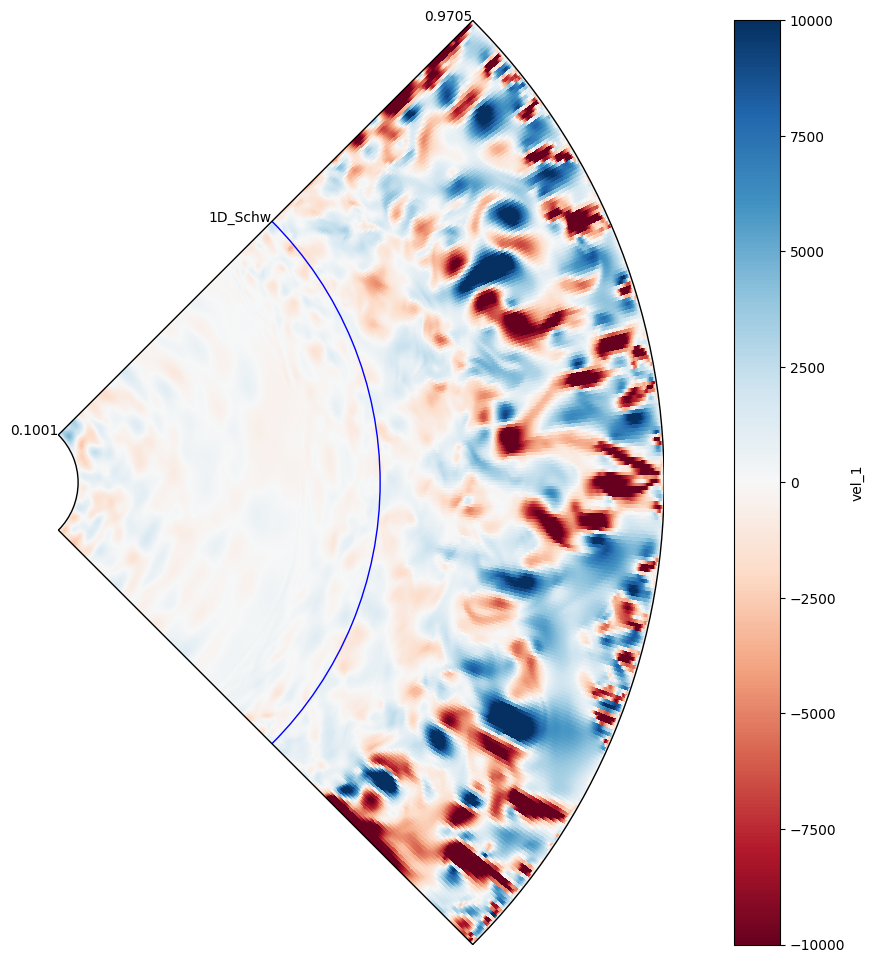

In [21]:
example_plot = cj_plotter.plot2D(t, r/r_tot, vel_1, -1e4, 1e4, cmap='RdBu') # , visible_ax=False)

# example_plot.add_arc(5.149819426617924E+10/r_tot, edgecolor='blue', label='1D_Schw')
# example_plot.add_arc(55412016190.5/r_tot, edgecolor='blue', linestyle=':', label='kurt/skew')
example_plot.colorbar(label='vel_1')
example_plot.add_arc(5.149819426617924E+10/r_tot, edgecolor='blue', label='1D_Schw')

In [15]:
vel_1.shape

(864, 270)

In [17]:
vorticity = np.genfromtxt('scripts/data.csv',delimiter=',').T

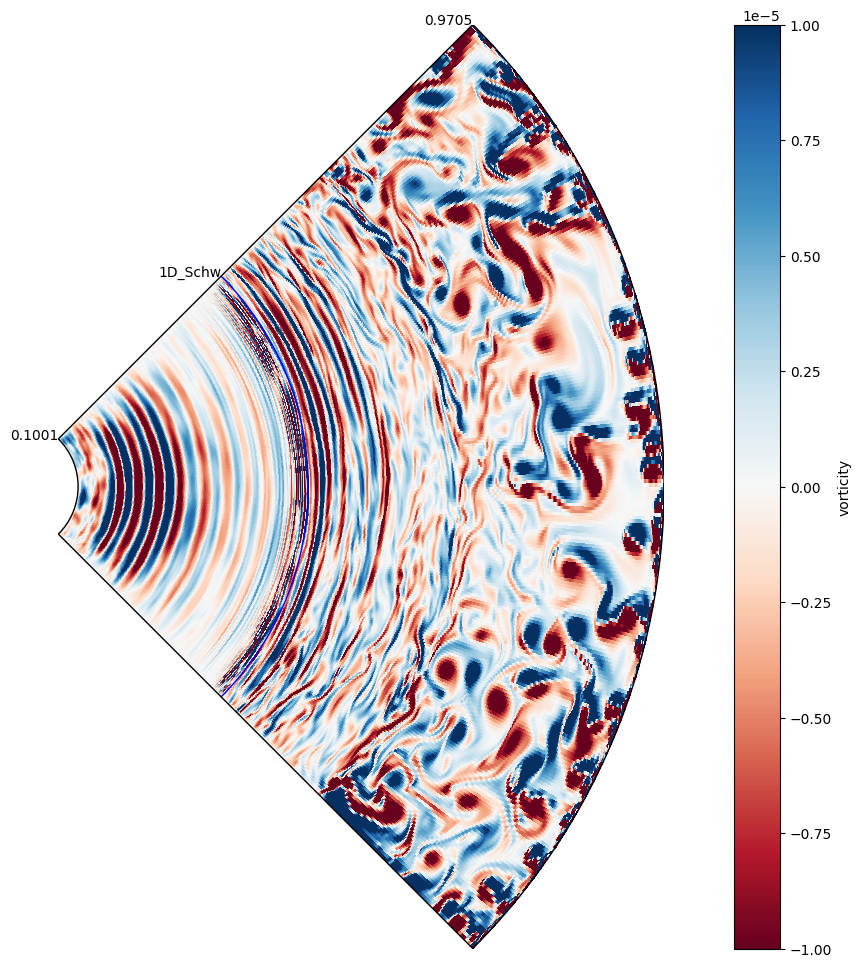

In [28]:
example_plot = cj_plotter.plot2D(t, r/r_tot, vorticity, -1e-5, 1e-5, cmap='RdBu') # , visible_ax=False)

# example_plot.add_arc(5.149819426617924E+10/r_tot, edgecolor='blue', label='1D_Schw')
# example_plot.add_arc(55412016190.5/r_tot, edgecolor='blue', linestyle=':', label='kurt/skew')
example_plot.colorbar(label='vorticity')
example_plot.add_arc(r_env_init/r_tot, edgecolor='blue', label='1D_Schw')